# Multilayer perceptron (NumPy) — Iris

Copia de trabajo de `04 Multilayer perceptron.ipynb`. Corre primero la red
original 4x3x3 y despues agrega dos capas ocultas mas (4x3x3x3x3), sin
cambiar sigmoide, alpha=0.03 ni 500 epocas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")

In [3]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 50
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 100
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]
[7.  3.2 4.7 1.4]
1
[0 1 0]
[6.3 3.3 6.  2.5]
2
[0 0 1]


## Red generalizada (N capas)

Se reemplazan las funciones de la notebook original (pensadas para 2 capas fijas) por una version generalizada que acepta cualquier lista de tamanos `[n_entradas, n_capa1, ..., n_salida]`. El forward y el backprop recorren la lista de capas, asi que agregar mas capas no es solo declarar mas listas: el backprop tambien las usa.

In [4]:
def generate_weights(num_weights):
  w = np.zeros(num_weights)
  for i in range(len(w)):
    w[i] = float(np.random.rand(1)[0] - 0.5)
  return w

def sigmoid(z):
  return 1 / (1 + np.power(np.e, -z))

def net_input(input_vector, w):
  s = w[0]
  for i in range(len(input_vector)):
    s += w[i + 1] * input_vector[i]
  return s

def propagate(x, w):
  return sigmoid(net_input(x, w))

def make_network(sizes):
  """sizes = [n_entradas, n_capa1, ..., n_salida]"""
  layers = []
  for l in range(1, len(sizes)):
    n_in, n_out = sizes[l - 1], sizes[l]
    layer = [generate_weights(n_in + 1) for _ in range(n_out)]
    layers.append(layer)
  return layers

def forward(x, layers):
  """Etapa 1 - Propagacion. Devuelve [entrada, salida_capa1, ..., salida_capaN]."""
  activations = [np.asarray(x)]
  a = x
  for layer in layers:
    out = np.zeros(len(layer))
    for i in range(len(layer)):
      out[i] = propagate(a, layer[i])
    activations.append(out)
    a = out
  return activations

def calculate_error(X, Y, layers):
  total = 0.0
  for idx in range(len(X)):
    acts = forward(X[idx], layers)
    err = Y[idx] - acts[-1]
    total += np.power(err, 2).sum()
  return total / len(X)

def train(sizes, alpha=0.03, epochs=500, seed=42, log_every=None):
  np.random.seed(seed)
  layers = make_network(sizes)
  E = [calculate_error(X, Y, layers)]
  for e in range(epochs):
    for d in range(len(X)):
      acts = forward(X[d], layers)

      # Etapa 2 - Retropropagacion, de la capa de salida hacia la entrada.
      n_layers = len(layers)
      deltas = [None] * n_layers
      out = acts[-1]
      deltas[-1] = out * (1 - out) * (Y[d] - out)
      for l in range(n_layers - 2, -1, -1):
        out_l = acts[l + 1]
        next_layer = layers[l + 1]
        next_delta = deltas[l + 1]
        weighted = np.zeros(len(out_l))
        for i in range(len(out_l)):
          s = 0.0
          for j in range(len(next_layer)):
            s += next_layer[j][i + 1] * next_delta[j]
          weighted[i] = s
        deltas[l] = out_l * (1 - out_l) * weighted

      for l in range(n_layers):
        layer_input = acts[l]
        for i in range(len(layers[l])):
          layers[l][i][0] += alpha * deltas[l][i] * 1
          for j in range(len(layer_input)):
            layers[l][i][j + 1] += alpha * deltas[l][i] * layer_input[j]

    err = calculate_error(X, Y, layers)
    E.append(err)
    if log_every and (e + 1) % log_every == 0:
      print(f"  epoch {e+1}: error={err:.5f}")
  return E, layers

## Red original (4 x 3 x 3)

Error final (original): 0.0596076132869433


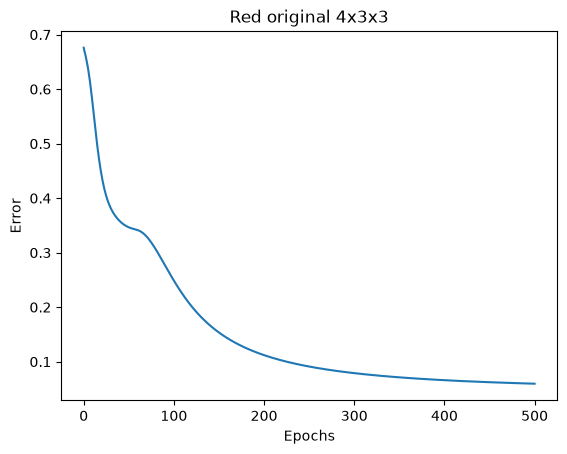

In [5]:
E_orig, layers_orig = train([4, 3, 3], alpha=0.03, epochs=500)
print("Error final (original):", E_orig[-1])
plt.plot(E_orig)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Red original 4x3x3")
plt.show()

## Red profunda (4 x 3 x 3 x 3 x 3)

Dos capas ocultas mas, todas sigmoide, mismos alpha y epocas. La salida sigue siendo de 3 neuronas.

Error final (profunda): 0.40642383281796524


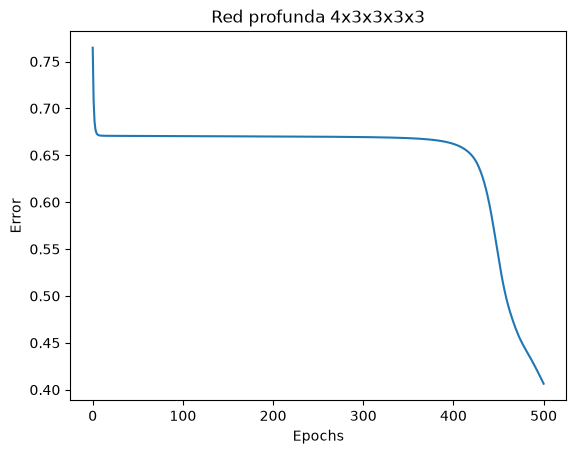

In [6]:
E_deep, layers_deep = train([4, 3, 3, 3, 3], alpha=0.03, epochs=500)
print("Error final (profunda):", E_deep[-1])
plt.plot(E_deep)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Red profunda 4x3x3x3x3")
plt.show()

## Comparacion original vs. profunda

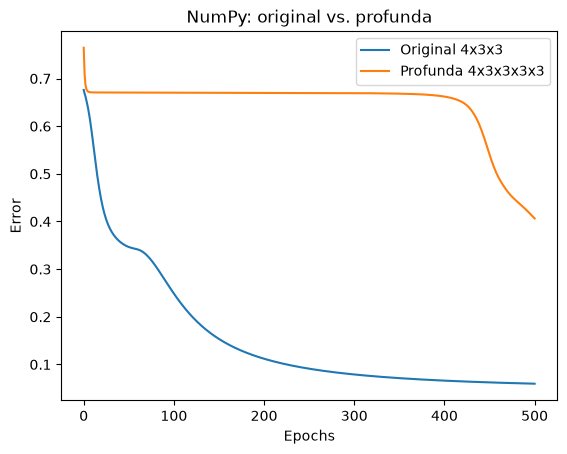

Error final original: 0.05961
Error final profunda: 0.40642


In [7]:
plt.plot(E_orig, label="Original 4x3x3")
plt.plot(E_deep, label="Profunda 4x3x3x3x3")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.title("NumPy: original vs. profunda")
plt.show()
print(f"Error final original: {E_orig[-1]:.5f}")
print(f"Error final profunda: {E_deep[-1]:.5f}")

## Reto opcional

### a) Error cada 50 epocas (ambas topologias)

In [8]:
print("--- Original 4x3x3 ---")
_ = train([4, 3, 3], alpha=0.03, epochs=500, log_every=50)
print("--- Profunda 4x3x3x3x3 ---")
_ = train([4, 3, 3, 3, 3], alpha=0.03, epochs=500, log_every=50)

--- Original 4x3x3 ---


  epoch 50: error=0.34648


  epoch 100: error=0.24869


  epoch 150: error=0.15346


  epoch 200: error=0.11199


...

  epoch 300: error=0.66942


  epoch 350: error=0.66828


  epoch 400: error=0.66215


  epoch 450: error=0.54063


  epoch 500: error=0.40642


### b) Mas neuronas por capa oculta (4 x 8 x 8 x 8 x 3)

Error final (4x8x8x8x3): 0.06496536072401514


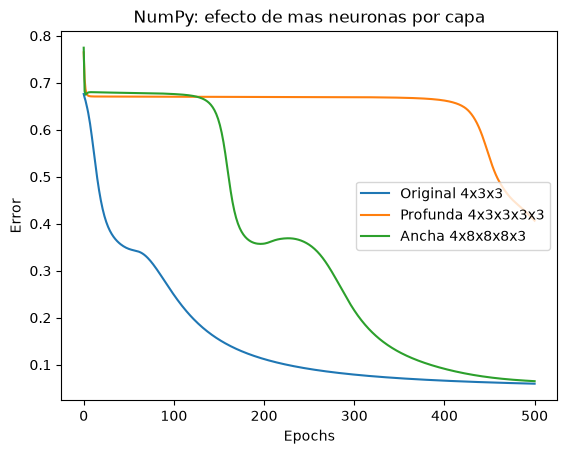

In [9]:
E_wide, layers_wide = train([4, 8, 8, 8, 3], alpha=0.03, epochs=500)
print("Error final (4x8x8x8x3):", E_wide[-1])
plt.plot(E_orig, label="Original 4x3x3")
plt.plot(E_deep, label="Profunda 4x3x3x3x3")
plt.plot(E_wide, label="Ancha 4x8x8x8x3")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.title("NumPy: efecto de mas neuronas por capa")
plt.show()